<a href="https://colab.research.google.com/github/omarmkhallati/AI_For_Cybersecurity-Mkhallati/blob/main/Appling_AI_for_Network_Traffic_Analysis_A_Practical_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

Before building an AI model, the required Python libraries must be imported. These libraries provide ready-made functions for generating data, preprocessing it, training machine learning models, and visualizing results, making AI development faster and more efficient.

*   **NumPy** (numpy) is used for numerical computations and generating the simulated network traffic data.
*   **Isolation Forest** (IsolationForest) from Scikit-learn is an unsupervised machine learning algorithm used to detect abnormal network traffic without requiring labeled attack data.
*   **StandardScaler** (StandardScaler) normalizes the input features so they have similar scales, improving the performance of the machine learning model.
*   **Matplotlib** (pyplot) is used to create graphs and scatter plots that visually distinguish normal network traffic from detected anomalies.

These libraries provide the essential tools needed to prepare the data, train the AI model, and visualize the anomaly detection results.

In [13]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# **Generate data, train the Isolation Forest model, and visualise**

In this example, synthetic network traffic is generated to demonstrate how an AI model can detect suspicious network connections. The dataset contains mostly normal traffic and a small number of anomalous connections, creating a realistic cybersecurity scenario.

* **Normal traffic** consists of 1,000 network connections with typical packet lengths and inter-arrival times.
* **Anomalous traffic** consists of 50 connections with unusually large packet sizes and longer inter-arrival times, representing potential cyber threats.
* Both datasets are combined into a single dataset, where normal traffic greatly outnumbers malicious traffic.
* The data is **standardized** using **StandardScaler** so that all features contribute equally during model training.
* An **Isolation Forest** model is trained to identify unusual network behavior without requiring labeled attack data.
* The model classifies each network connection as either **normal (1)** or **anomalous (-1)**.
* Finally, the results are displayed using a **scatter plot**, allowing users to visually distinguish normal network traffic from detected anomalies.

This workflow demonstrates the complete AI-based anomaly detection process, from data generation and preprocessing to model training, prediction, and visualization.

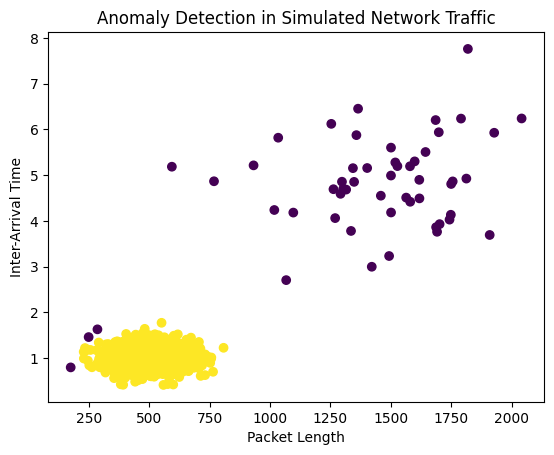

In [14]:
# Simulate normal traffic: mean packet length 500, std 100; inter-arrival 1s, std 0.2
np.random.seed(42)
normal_traffic = np.random.normal(loc=[500, 1], scale=[100, 0.2], size=(1000, 2))

# Anomalies: larger packets or irregular timing
anomalies = np.random.normal(loc=[1500, 5], scale=[300, 1], size=(50, 2))

# Combine datasets
data = np.vstack([normal_traffic, anomalies])

# Scale features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(data_scaled)

# Predict anomalies (-1 for anomaly, 1 for normal)
predictions = model.predict(data_scaled)

# Visualize
plt.scatter(data[:, 0], data[:, 1], c=predictions, cmap='viridis')
plt.xlabel('Packet Length')
plt.ylabel('Inter-Arrival Time')
plt.title('Anomaly Detection in Simulated Network Traffic')
plt.show()

# **Train the Autoencoder model**

In this part, a **deep learning Autoencoder** is used to detect anomalous network traffic. An autoencoder learns the normal patterns of network data by reconstructing its input, making it effective for identifying unusual or previously unseen cyber threats.

* **TensorFlow and Keras** are used to build and train the autoencoder neural network.
* The autoencoder compresses the input data into a smaller representation and then reconstructs it, learning the key characteristics of normal network traffic.
* The model is trained using **standardized network data** without requiring labels, making it an **unsupervised learning approach**.
* During training, the model minimizes the **Mean Squared Error (MSE)** between the original and reconstructed data using the **Adam optimizer**.
* After training, the **reconstruction error** is calculated for each network connection.
* Connections with reconstruction errors above the **95th percentile threshold** are classified as **anomalies**, while the remaining connections are considered normal.
* The final output identifies suspicious network traffic as **True** (anomalous) or **False** (normal).

This approach demonstrates how deep learning can detect unknown attacks, insider threats, and zero-day exploits by learning normal network behavior instead of relying on predefined attack signatures.

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Assume data_scaled from above
autoencoder = Sequential([
    Dense(32, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(data_scaled, data_scaled, epochs=50, batch_size=32)

# Reconstruction error
reconstructions = autoencoder.predict(data_scaled)
mse = np.mean(np.power(data_scaled - reconstructions, 2), axis=1)

# Threshold for anomalies (e.g., 95th percentile)
threshold = np.percentile(mse, 95)
anomalies_detected = mse > threshold

Epoch 1/50


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7396   
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 0.2190
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 0.0722
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 0.0408
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.0211
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 0.0103
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 0.0055
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.0036   
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 0.0025
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0019     
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.0015   
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.0013   
Epoch 13/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 9.4073e-04
Epoch 14/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss: 8.2504e-04
Epoch 15/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 925us

The previous output is the training progress. During each epoch, the autoencoder updates its weights to reduce the reconstruction error between the original network traffic and its reconstructed version. As training continues, the loss value should gradually decrease, indicating that the model is becoming better at learning the normal characteristics of the network traffic.

In [16]:
print(anomalies_detected)

[False False False ... False False  True]


In [17]:
for i in range(10):
    print(f"Record {i+1}: MSE = {mse[i]:.5f}, Anomaly = {anomalies_detected[i]}")

Record 1: MSE = 0.00001, Anomaly = False
Record 2: MSE = 0.00001, Anomaly = False
Record 3: MSE = 0.00001, Anomaly = False
Record 4: MSE = 0.00000, Anomaly = False
Record 5: MSE = 0.00001, Anomaly = False
Record 6: MSE = 0.00001, Anomaly = False
Record 7: MSE = 0.00005, Anomaly = False
Record 8: MSE = 0.00003, Anomaly = False
Record 9: MSE = 0.00002, Anomaly = False
Record 10: MSE = 0.00002, Anomaly = False


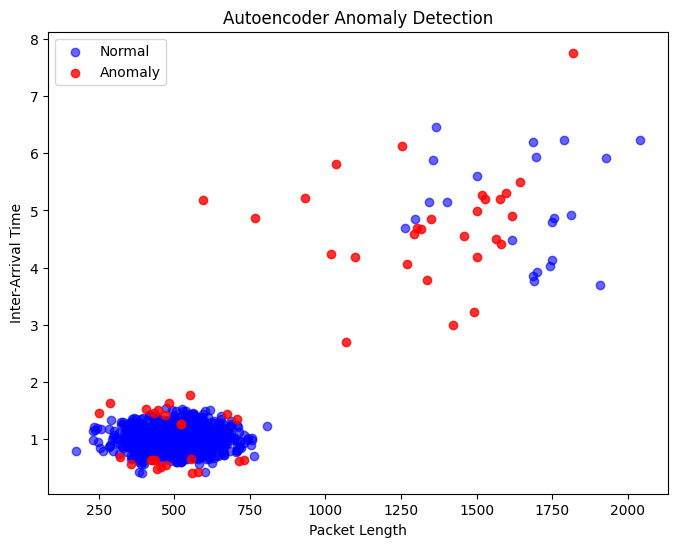

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot normal traffic
plt.scatter(
    data[~anomalies_detected, 0],
    data[~anomalies_detected, 1],
    c='blue',
    label='Normal',
    alpha=0.6
)

# Plot anomalies
plt.scatter(
    data[anomalies_detected, 0],
    data[anomalies_detected, 1],
    c='red',
    label='Anomaly',
    alpha=0.8
)

plt.xlabel("Packet Length")
plt.ylabel("Inter-Arrival Time")
plt.title("Autoencoder Anomaly Detection")
plt.legend()
plt.show()

After the autoencoder has been trained, it attempts to reconstruct every network connection in the dataset. The quality of this reconstruction indicates whether the traffic is normal or anomalous.

